# 11 · Piotroski F-score screen

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/11_piotroski_screen.ipynb)

**What you will learn**

- What the nine tests of the Piotroski F-score measure.
- How to screen the S&P 500 on the F-score exactly as it was known on a date.
- How to rebuild the nine tests for one company from reported facts, to see what drives its score.

**Plan required:** none (free sample tier).

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. The score

Joseph Piotroski (2000) scored companies 0 to 9, one point per test passed, comparing the latest
fiscal year with the year before:

| Group | Test (one point if true) |
|---|---|
| Profitability | net income > 0 · operating cash flow > 0 · return on assets rose · operating cash flow > net income |
| Leverage and liquidity | long-term debt to assets fell · current ratio rose · no new shares issued |
| Efficiency | gross margin rose · asset turnover rose |

High scores (7 to 9) mark improving fundamentals; low scores (0 to 2) deteriorating ones.
Valuein publishes the score in the `ratio` table as `piotroski_f_score`, one value per fiscal
year, available from the moment the 10-K is accepted.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()
AS_OF = "2025-06-30"

members = client.universe(dates=[AS_OF])
panel = client.signal_panel(members, ratios=["piotroski_f_score"], include_price=False)
scored = panel.dropna(subset=["piotroski_f_score"])
print(f"S&P 500 members on {AS_OF}: {len(panel)}, with a known F-score: {len(scored)}")


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


S&P 500 members on 2025-06-30: 499, with a known F-score: 458


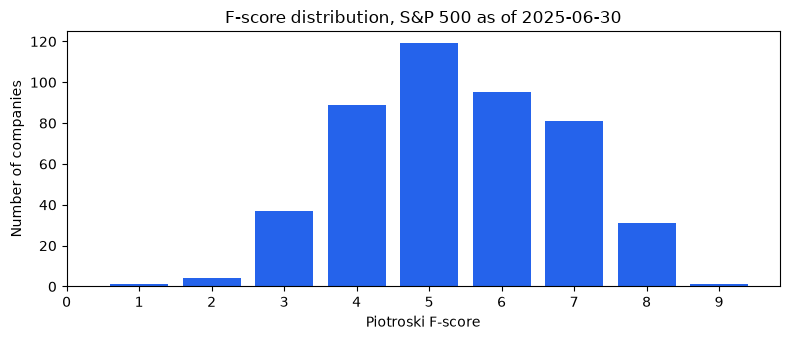

In [3]:
counts = scored["piotroski_f_score"].astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(counts.index, counts.values, color="#2563eb")
ax.set_xticks(range(10))
ax.set_xlabel("Piotroski F-score")
ax.set_ylabel("Number of companies")
ax.set_title(f"F-score distribution, S&P 500 as of {AS_OF}")
plt.tight_layout()
plt.show()

## 2. Strongest and weakest

In [4]:
columns = ["ticker", "name", "sector", "piotroski_f_score"]
strong = scored[scored["piotroski_f_score"] >= 8].sort_values(["piotroski_f_score", "ticker"], ascending=[False, True])
weak = scored[scored["piotroski_f_score"] <= 2].sort_values(["piotroski_f_score", "ticker"])
print(f"{len(strong)} companies score 8 or 9; {len(weak)} score 2 or less")
pd.concat([strong[columns].head(8), weak[columns].head(8)])

32 companies score 8 or 9; 5 score 2 or less


,ticker,name,sector,piotroski_f_score
33,ANSS,ANSYS INC,Information Technology,9.0
8,ADI,ANALOG DEVICES INC,Information Technology,8.0
26,AMD,ADVANCED MICRO DEVICES INC,Information Technology,8.0
27,AME,AMETEK INC/,Industrials,8.0
35,AOS,SMITH A O CORP,Information Technology,8.0
45,AVY,Avery Dennison Corp,Materials,8.0
86,CHD,CHURCH & DWIGHT CO INC /DE/,Health Care,8.0
91,CL,COLGATE PALMOLIVE CO,Health Care,8.0
122,CZR,"Caesars Entertainment, Inc.",Consumer Discretionary,1.0
50,BA,BOEING CO,Industrials,2.0


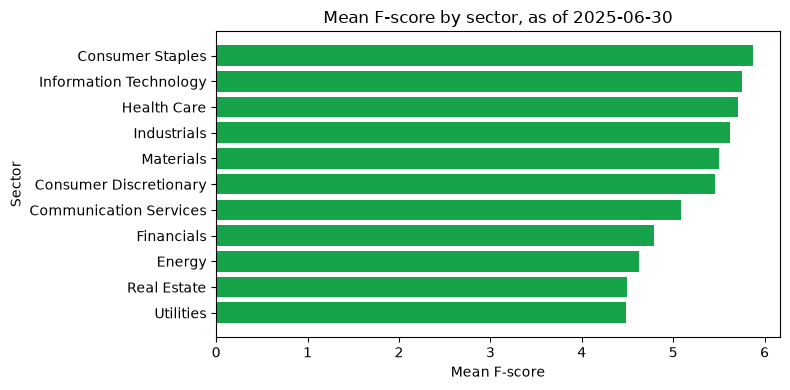

In [5]:
by_sector = scored.groupby("sector")["piotroski_f_score"].agg(["mean", "count"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_sector.index, by_sector["mean"], color="#16a34a")
ax.set_xlabel("Mean F-score")
ax.set_ylabel("Sector")
ax.set_title(f"Mean F-score by sector, as of {AS_OF}")
plt.tight_layout()
plt.show()

## 3. Inside one score

The nine tests need two consecutive fiscal years of nine facts. Rebuilding them for one company
shows which tests it passed. This is our reading of the 2000 paper (return on assets uses
year-end assets, leverage uses long-term debt over total assets); data vendors, Valuein's
pipeline included, differ in such details, so a recomputed score can differ by a point from the
published one.

In [6]:
TICKER = "AAPL"
cik = client.resolve(TICKER)["cik"].iloc[0]
needed = ["NetIncome", "OperatingCashFlow", "TotalAssets", "LongTermDebt", "CurrentAssets",
          "TotalCurrentLiabilities", "WeightedAvgSharesDiluted", "GrossProfit", "TotalRevenue"]
names = ", ".join(f"'{c}'" for c in needed)
facts = client.run_query(f"""
    SELECT period_end, standard_concept, numeric_value
    FROM fact
    WHERE entity_id = '{cik}' AND standard_concept IN ({names}) AND fiscal_period = 'FY'
      AND accepted_at <= TIMESTAMP '{AS_OF}'
      AND (period_span_days BETWEEN 350 AND 380 OR period_start IS NULL)
    QUALIFY ROW_NUMBER() OVER (PARTITION BY standard_concept, period_end ORDER BY accepted_at DESC, priority DESC) = 1
""").pivot(index="period_end", columns="standard_concept", values="numeric_value").sort_index()

now, before = facts.iloc[-1], facts.iloc[-2]


def roa(year: pd.Series) -> float:
    """Return on assets: net income over year-end total assets."""
    return year["NetIncome"] / year["TotalAssets"]


tests = {
    "net income > 0": now["NetIncome"] > 0,
    "operating cash flow > 0": now["OperatingCashFlow"] > 0,
    "return on assets rose": roa(now) > roa(before),
    "cash flow > net income": now["OperatingCashFlow"] > now["NetIncome"],
    "long-term debt / assets fell": now["LongTermDebt"] / now["TotalAssets"] < before["LongTermDebt"] / before["TotalAssets"],
    "current ratio rose": now["CurrentAssets"] / now["TotalCurrentLiabilities"] > before["CurrentAssets"] / before["TotalCurrentLiabilities"],
    "no dilution": now["WeightedAvgSharesDiluted"] <= before["WeightedAvgSharesDiluted"],
    "gross margin rose": now["GrossProfit"] / now["TotalRevenue"] > before["GrossProfit"] / before["TotalRevenue"],
    "asset turnover rose": now["TotalRevenue"] / now["TotalAssets"] > before["TotalRevenue"] / before["TotalAssets"],
}
print(f"{TICKER}: fiscal year {facts.index[-1]:%Y-%m-%d} vs {facts.index[-2]:%Y-%m-%d}")
for test, passed in tests.items():
    print(f"  {'pass' if passed else 'fail'}  {test}")
published = scored.loc[scored["ticker"] == TICKER, "piotroski_f_score"]
print(f"recomputed score: {sum(bool(v) for v in tests.values())}   published: "
      f"{int(published.iloc[0]) if len(published) else 'n/a'}")

AAPL: fiscal year 2024-09-28 vs 2023-09-30
  pass  net income > 0
  pass  operating cash flow > 0
  fail  return on assets rose
  pass  cash flow > net income
  pass  long-term debt / assets fell
  fail  current ratio rose
  pass  no dilution
  pass  gross margin rose
  fail  asset turnover rose
recomputed score: 6   published: 6


In [7]:
client.close()

## Next steps

- Does the F-score predict returns in this universe? Notebook 04 backtests `piotroski_f_score`
  next to other signals, with costs and point-in-time data.
- **[12 · Earnings quality](12_earnings_quality.ipynb)**: accruals, the cash-flow side of quality.